In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ripser import ripser

In [2]:
df = pd.read_csv('archive/1_min_SPY_2008-2021.csv', parse_dates=['date'], index_col='date')
close_prices = df['close'].values

In [3]:
df.head()

,Unnamed: 0,open,high,low,close,volume,barCount,average
date,,,,,,,,
2009-05-22 07:30:00,0,89.45,89.46,89.37,89.37,7872,2102,89.424
2009-05-22 07:31:00,1,89.38,89.53,89.37,89.50,5336,1938,89.468
2009-05-22 07:32:00,2,89.51,89.54,89.48,89.49,3349,1184,89.516
2009-05-22 07:33:00,3,89.49,89.49,89.31,89.34,3495,1240,89.386
2009-05-22 07:34:00,4,89.33,89.46,89.33,89.39,9731,2637,89.379


Rozpoczynam obliczenia TDA dla 4699 okien...
Obliczenia zakończone.


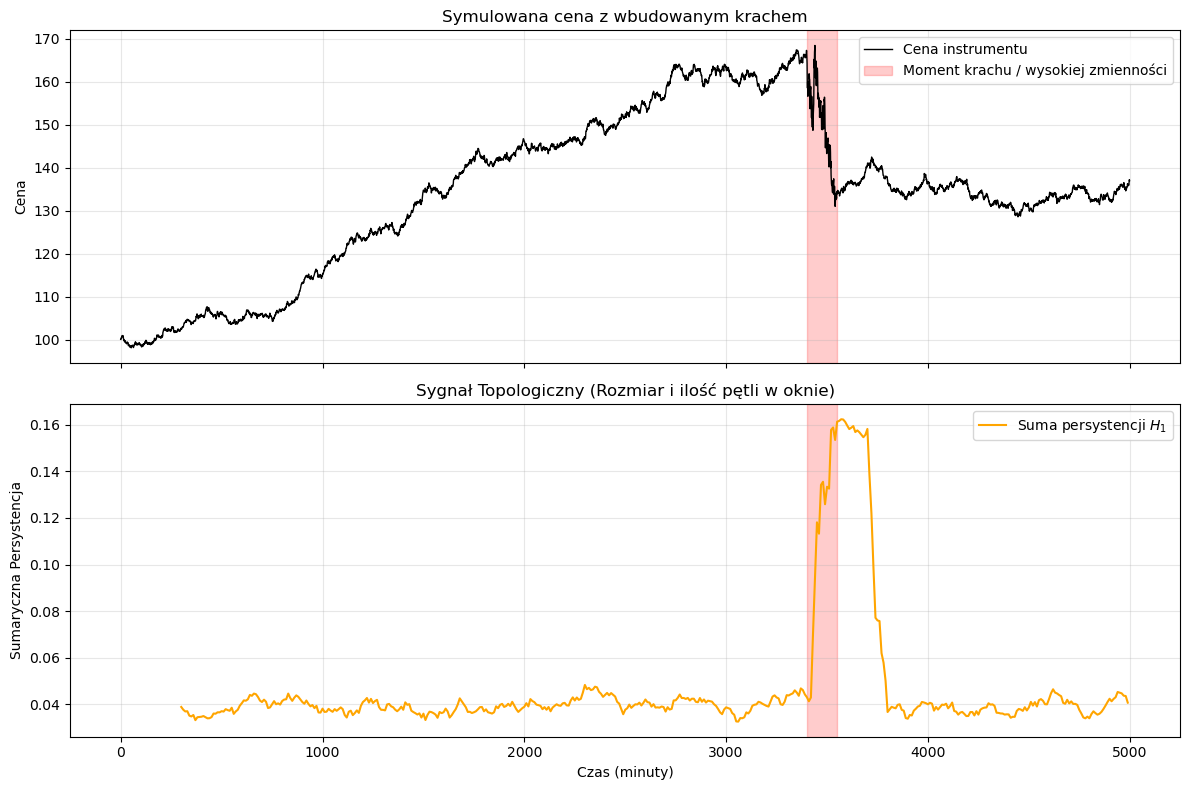

In [ ]:
def takens_embedding(series, delay, dimension):
    n = len(series) - (dimension - 1) * delay
    if n <= 0:
        return np.array([])
    # Wycinamy przesunięte wektory
    embedded = np.array([series[i : i + dimension * delay : delay] for i in range(n)])
    return embedded



# Na potrzeby testu kodu generujemy syntetyczny geometryczny ruch Browna z "krachem"
np.random.seed(42)
n_points = 5000
returns = np.random.normal(0.0001, 0.002, n_points)
# Symulacja nagłego wzrostu zmienności i krachu w okolicach indeksu 3500
returns[3400:3550] = np.random.normal(-0.002, 0.015, 150) 
close_prices = 100 * np.exp(np.cumsum(returns))

# Obliczamy log-zwroty
log_returns = np.diff(np.log(close_prices))

# 3. Parametry eksperymentu
window_size = 300    # Długość kroczącego okna w minutach
delay = 2            # Opóźnienie (tau) w zanurzeniu Takensa
dimension = 4        # Wymiar chmury punktów (d)
step = 10            # Przesuwamy okno co 10 minut (dla przyspieszenia obliczeń)

# Tablice na wyniki
timestamps = []
h1_total_persistence = []

print(f"Rozpoczynam obliczenia TDA dla {len(log_returns) - window_size} okien...")

# 4. Główna pętla
for i in range(0, len(log_returns) - window_size, step):
    window_data = log_returns[i : i + window_size]
    
    # Tworzymy chmurę punktów
    point_cloud = takens_embedding(window_data, delay, dimension)
    
    if len(point_cloud) < dimension + 1:
        continue # Pomijamy, jeśli mamy za mało punktów
        
    # Obliczamy homologię persystentną (interesuje nas max wymiar 1)
    # ripser radzi sobie najlepiej z macierzami odległości, 
    # ale przyjmuje też chmury punktów i sam liczy metrykę euklidesową
    res = ripser(point_cloud, maxdim=1)
    diagrams = res['dgms']
    
    # Diagram dla H_1 (pętle)
    h1_diagram = diagrams[1]
    
    if len(h1_diagram) > 0:
        # Filtrujemy cechy o nieskończonym czasie życia (choć w H_1 rzadkie)
        valid_features = h1_diagram[h1_diagram[:, 1] != np.inf]
        if len(valid_features) > 0:
            # Obliczamy "czas życia" (death - birth) każdej pętli
            lifespans = valid_features[:, 1] - valid_features[:, 0]
            # Sumujemy czasy życia jako prostą miarę (proxy entropii L1)
            total_pers = np.sum(lifespans)
        else:
            total_pers = 0.0
    else:
        total_pers = 0.0
        
    h1_total_persistence.append(total_pers)
    # Zapisujemy indeks środka lub końca okna do wykresu
    timestamps.append(i + window_size)

print("Obliczenia zakończone.")

# 5. Wizualizacja
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Wykres cen
ax1.plot(close_prices, label='Cena instrumentu', color='black', linewidth=1)
ax1.axvspan(3400, 3550, color='red', alpha=0.2, label='Moment krachu / wysokiej zmienności')
ax1.set_title('Symulowana cena z wbudowanym krachem')
ax1.set_ylabel('Cena')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Wykres sygnału topologicznego
ax2.plot(timestamps, h1_total_persistence, label='Suma persystencji $H_1$', color='orange', linewidth=1.5)
ax2.set_title('Sygnał Topologiczny (Rozmiar i ilość pętli w oknie)')
ax2.set_xlabel('Czas (minuty)')
ax2.set_ylabel('Sumaryczna Persystencja')
ax2.axvspan(3400, 3550, color='red', alpha=0.2)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Rozpoczynam obliczenia TDA dla 4699 okien i 6 wymiarów...
Obliczenia zakończone. Generowanie wykresu...


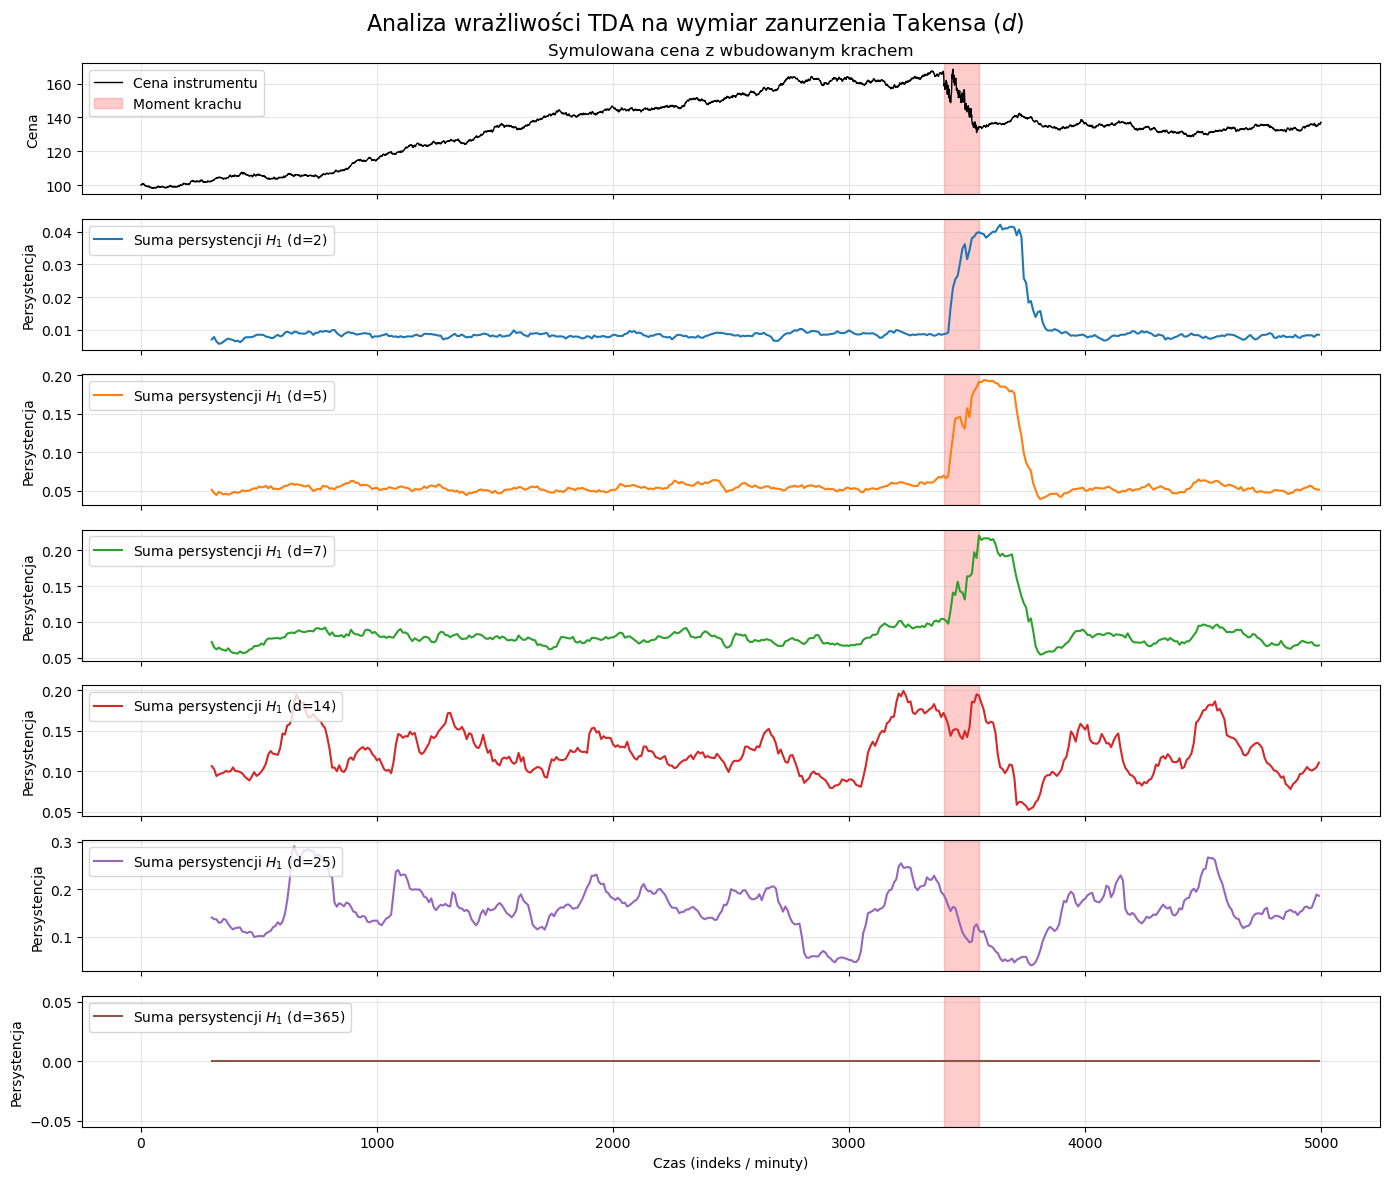

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser

def takens_embedding(series, delay, dimension):
    """
    Tworzy chmurę punktów z jednowymiarowego szeregu czasowego.
    """
    n = len(series) - (dimension - 1) * delay
    if n <= 0:
        return np.array([])
    embedded = np.array([series[i : i + dimension * delay : delay] for i in range(n)])
    return embedded

# 1. Generowanie danych (geometryczny ruch Browna z krachem)
np.random.seed(42)
n_points = 5000
returns = np.random.normal(0.0001, 0.002, n_points)
# Symulacja nagłego wzrostu zmienności i krachu
crash_start, crash_end = 3400, 3550
returns[crash_start:crash_end] = np.random.normal(-0.002, 0.015, crash_end - crash_start) 
close_prices = 100 * np.exp(np.cumsum(returns))
log_returns = np.diff(np.log(close_prices))

# 2. Parametry eksperymentu
window_size = 300    # Długość okna
delay = 2            # Opóźnienie (tau)
step = 10            # Przesunięcie okna
dimensions_to_test = [2,5,7,14,25,365] # Testowane wymiary zanurzenia

timestamps = []
# Słownik do przechowywania wyników dla każdego wymiaru
results_h1 = {d: [] for d in dimensions_to_test}

print(f"Rozpoczynam obliczenia TDA dla {len(log_returns) - window_size} okien i {len(dimensions_to_test)} wymiarów...")

# 3. Główna pętla
for i in range(0, len(log_returns) - window_size, step):
    window_data = log_returns[i : i + window_size]
    timestamps.append(i + window_size)
    
    for d in dimensions_to_test:
        point_cloud = takens_embedding(window_data, delay, d)
        
        if len(point_cloud) < d + 1:
            results_h1[d].append(0.0)
            continue
            
        # Obliczamy homologię persystentną
        res = ripser(point_cloud, maxdim=1)
        diagrams = res['dgms']
        h1_diagram = diagrams[1]
        
        if len(h1_diagram) > 0:
            valid_features = h1_diagram[h1_diagram[:, 1] != np.inf]
            if len(valid_features) > 0:
                lifespans = valid_features[:, 1] - valid_features[:, 0]
                total_pers = np.sum(lifespans)
            else:
                total_pers = 0.0
        else:
            total_pers = 0.0
            
        results_h1[d].append(total_pers)

print("Obliczenia zakończone. Generowanie wykresu...")

# 4. Wizualizacja
fig, axes = plt.subplots(len(dimensions_to_test) + 1, 1, figsize=(14, 12), sharex=True)

# Wykres cen (pierwszy na górze)
axes[0].plot(close_prices, label='Cena instrumentu', color='black', linewidth=1)
axes[0].axvspan(crash_start, crash_end, color='red', alpha=0.2, label='Moment krachu')
axes[0].set_title('Symulowana cena z wbudowanym krachem')
axes[0].set_ylabel('Cena')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Wykresy sygnałów topologicznych dla kolejnych wymiarów
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', "#8c564b", "#e377c2", "#7f7f7f"]

for idx, d in enumerate(dimensions_to_test):
    ax = axes[idx + 1]
    ax.plot(timestamps, results_h1[d], label=f'Suma persystencji $H_1$ (d={d})', color=colors[idx], linewidth=1.5)
    ax.axvspan(crash_start, crash_end, color='red', alpha=0.2)
    ax.set_ylabel('Persystencja')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Czas (indeks / minuty)')
plt.suptitle('Analiza wrażliwości TDA na wymiar zanurzenia Takensa ($d$)', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

# Section 2: short term

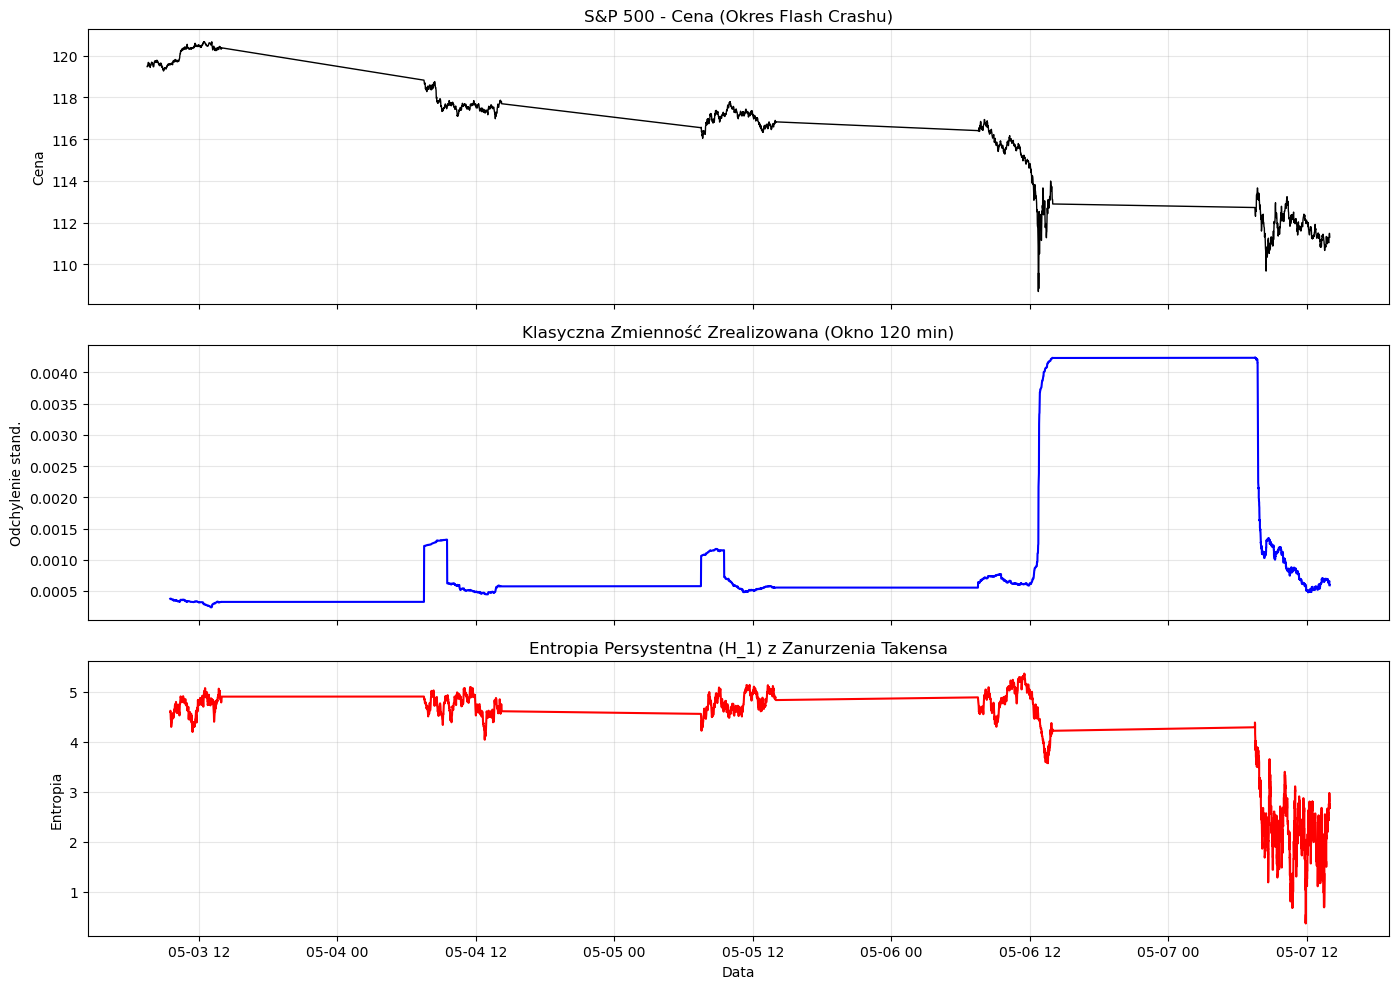

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ripser import ripser

# ---------------------------------------------------------
# 1. PRZYGOTOWANIE DANYCH
# ---------------------------------------------------------
# Zakładam, że masz już wczytany df. 
# Wycinamy tydzień wokół Flash Crashu (6 maja 2010)

# Sort the index to ensure it's monotonic
df = df.sort_index()

df_crash = df.loc['2010-05-03':'2010-05-07'].copy()
close_prices = df_crash['close'].values

# Przechodzimy na log-zwroty (standard w finansach, stabilizuje wariancję)
log_returns = np.diff(np.log(close_prices))
dates = df_crash.index[1:]

# ---------------------------------------------------------
# 2. PARAMETRY EKSPERYMENTU
# ---------------------------------------------------------
WINDOW_SIZE = 120      # okno 60-minutowe
DIMENSION = 5         # wymiar zanurzenia (embedding dimension)
DELAY = 10             # opóźnienie (time delay \tau)

# ---------------------------------------------------------
# 3. FUNKCJE POMOCNICZE TDA
# ---------------------------------------------------------
def takens_embedding(series, dim, delay):
    """Tworzy chmurę punktów na podstawie Twierdzenia Takensa."""
    N = len(series)
    if N - (dim - 1) * delay <= 0:
        return np.array([])
    
    embedded = np.array([series[i : i + dim * delay : delay] 
                         for i in range(N - (dim - 1) * delay)])
    return embedded

def persistent_entropy(diagram):
    """Oblicza entropię persystentną Shannona dla danego wymiaru homologicznego."""
    # Odfiltrowujemy cechy o nieskończonym czasie życia
    finite_bars = diagram[diagram[:, 1] < np.inf]
    if len(finite_bars) == 0:
        return 0.0
    
    # Długość życia (death - birth)
    lifetimes = finite_bars[:, 1] - finite_bars[:, 0]
    L = np.sum(lifetimes)
    
    if L == 0:
        return 0.0
    
    # Prawdopodobieństwa
    p = lifetimes / L
    # Entropia Shannona
    entropy = -np.sum(p * np.log2(p + 1e-12))
    return entropy

# ---------------------------------------------------------
# 4. GŁÓWNA PĘTLA - ROLLING WINDOW
# ---------------------------------------------------------
tda_entropies = np.full(len(log_returns), np.nan)
realized_volatility = np.full(len(log_returns), np.nan)

# Przesuwamy się okno po oknie
for i in range(WINDOW_SIZE, len(log_returns)):
    window_data = log_returns[i - WINDOW_SIZE : i]
    
    # Klasyczna stochastyka: Zmienność zrealizowana (odchylenie standardowe)
    realized_volatility[i] = np.std(window_data)
    
    # TDA: Zanurzenie Takensa
    point_cloud = takens_embedding(window_data, DIMENSION, DELAY)
    
    # Zabezpieczenie przed pustą chmurą
    if len(point_cloud) > 2:
        try:
            # Liczymy homologie do H_1 (połączenia i pętle)
            result = ripser(point_cloud, maxdim=1)
            diagrams = result['dgms']
            
            # Liczymy entropię dla pętli (H_1), które często oznaczają anomalie
            if len(diagrams) > 1 and len(diagrams[1]) > 0:
                tda_entropies[i] = persistent_entropy(diagrams[1])
            else:
                tda_entropies[i] = 0.0
        except Exception as e:
            tda_entropies[i] = 0.0

# ---------------------------------------------------------
# 5. WIZUALIZACJA WYNIKÓW
# ---------------------------------------------------------
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Wykres 1: Cena
axs[0].plot(dates, close_prices[1:], color='black', linewidth=1)
axs[0].set_title('S&P 500 - Cena (Okres Flash Crashu)')
axs[0].set_ylabel('Cena')
axs[0].grid(True, alpha=0.3)

# Wykres 2: Klasyczna zmienność (szum stochastyczny)
axs[1].plot(dates, realized_volatility, color='blue', linewidth=1.5)
axs[1].set_title(f'Klasyczna Zmienność Zrealizowana (Okno {WINDOW_SIZE} min)')
axs[1].set_ylabel('Odchylenie stand.')
axs[1].grid(True, alpha=0.3)

# Wykres 3: Sygnał TDA (Entropia H_1)
axs[2].plot(dates, tda_entropies, color='red', linewidth=1.5)
axs[2].set_title('Entropia Persystentna (H_1) z Zanurzenia Takensa')
axs[2].set_ylabel('Entropia')
axs[2].set_xlabel('Data')
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()